# 01 — Bond Pricing & Risk Metrics

**Fixed Income Analytics** | Palma, R. (2026)

This notebook implements and validates all bond pricing formulas
derived in *Fixed Income Analytics*.

### Contents
1. Basic bond pricing (annual, T compoundings, continuous)
2. Yield to Maturity via Newton-Raphson
3. Duration, Convexity and DV01
4. Price approximation vs exact price
5. Bond parity
6. Roundtrip validation

In [7]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd

# Add src to path
sys.path.append("..")
from src.bonds import VanillaBond

# Plot style
plt.rcParams.update({
    "figure.figsize":  (12, 5),
    "axes.grid":       True,
    "grid.alpha":      0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family":     "serif"
})

print("Imports OK")

Imports OK


---
## 1. Bond Pricing

A vanilla bond with:
- **Coupon rate:** 5% annually
- **Face value:** $1,000
- **Maturity:** 10 years
- **Frequency:** annual

We price it under three compounding conventions and verify convergence.

In [8]:
# ---- Define bond ---- #
bond = VanillaBond(coupon_rate=0.05, face_value=1000,
                   maturity=10, frequency=1)
print(bond)

# ---- Three compounding conventions ---- #
r = 0.04  # discount rate

P_annual     = bond.bond_price(r)
P_continuous = bond.bond_price_continuous(r)

print(f"\nDiscount rate: {r:.2%}")
print(f"Price (annual):      {P_annual:.4f}")
print(f"Price (continuous):  {P_continuous:.4f}")
print(f"Difference:          {abs(P_annual - P_continuous):.6f}")
print(f"\nBond is trading at: {bond.parity(r)}")

VanillaBond(coupon_rate=5.00%, face_value=1000, maturity=10, frequency=1)

Discount rate: 4.00%
Price (annual):      1081.1090
Price (continuous):  1074.2329
Difference:          6.876023

Bond is trading at: Premium Bond:  P = 1081.1090 > F = 1000.00


### Convergence of T compoundings → continuous

As $T \to \infty$, the bond price converges to the continuous formula:
$$P = C \cdot \frac{1 - e^{-rn}}{e^r - 1} + F \cdot e^{-rn}$$

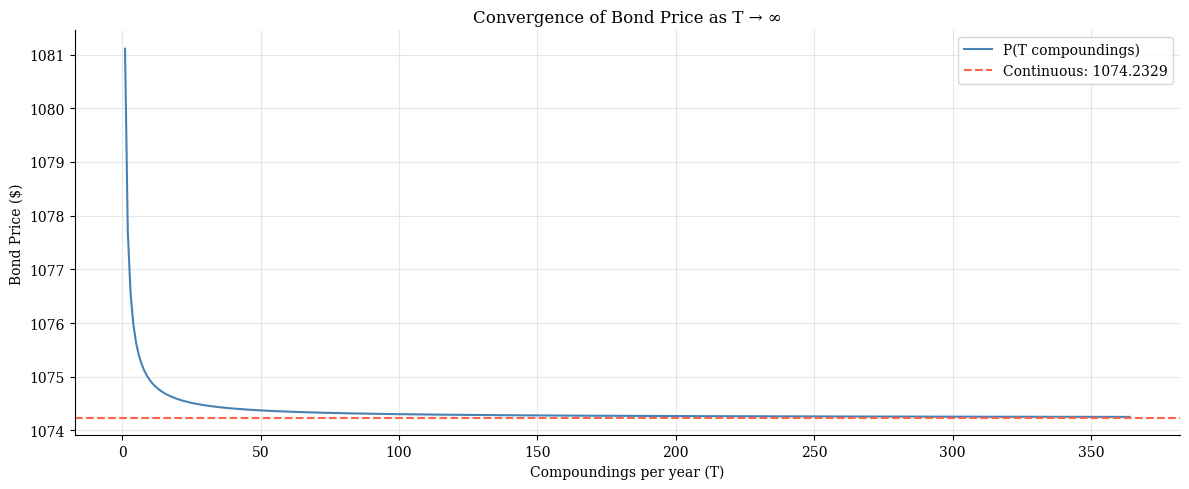

In [12]:
# ---- Price as function of compounding frequency T ---- #
frequencies = np.arange(1, 365)
prices = []

for T in frequencies:
    # Manually compute for arbitrary T (not restricted to 1,2,4,12)
    factor = (1 + r / T) ** (bond.T * T)
    denom  = (1 + r / T) ** T - 1
    P      = bond.C_annual * (1 - 1/factor) / denom + bond.F / factor
    prices.append(P)

P_cont = bond.bond_price_continuous(r)

fig, ax = plt.subplots()
ax.plot(frequencies, prices, color="steelblue", lw=1.5,
        label="P(T compoundings)")
ax.axhline(P_cont, color="tomato", lw=1.5, ls="--",
           label=f"Continuous: {P_cont:.4f}")
ax.set_xlabel("Compoundings per year (T)")
ax.set_ylabel("Bond Price ($)")
ax.set_title("Convergence of Bond Price as T → ∞")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/01_convergence.png", dpi=150)
plt.show()

---
## 2. Yield to Maturity

YTM is the rate $y$ that solves:
$$P = \sum_{i=1}^{n} \frac{CF_i}{(1+y)^i}$$

No closed-form solution → Newton-Raphson.
We verify: **bond_price(ytm(P)) = P** (roundtrip).

In [13]:
# ---- YTM from market price ---- #
market_price = 1081.1090  # observed market price

y = bond.ytm(market_price)
print(f"Market price:    {market_price:.2f}")
print(f"Implied YTM:     {y:.4%}")

# ---- Roundtrip validation ---- #
result = bond.validate_roundtrip(r=0.04)
print(f"\nRoundtrip validation:")
for k, v in result.items():
    print(f"  {k:20s}: {v}")

Market price:    1081.11
Implied YTM:     4.0000%

Roundtrip validation:
  original_price      : 1081.10895779
  recovered_ytm       : 0.04
  recovered_price     : 1081.10895779
  abs_error           : 0.0
  passed              : True


### Price-Yield Relationship

A fundamental property: **Price and yield are inversely related**

$$\uparrow y \Rightarrow \downarrow P \qquad \downarrow y \Rightarrow \uparrow P$$

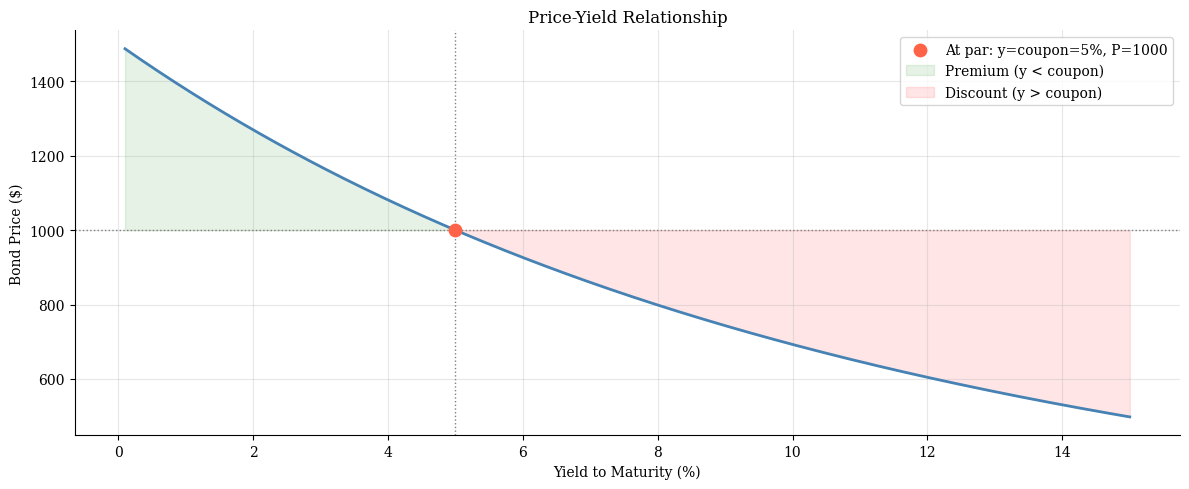

In [14]:
yields = np.linspace(0.001, 0.15, 300)
prices = [bond.bond_price(y) for y in yields]

coupon_rate = bond.C_annual / bond.F  # 5%
P_par       = bond.bond_price(coupon_rate)

fig, ax = plt.subplots()
ax.plot(yields * 100, prices, color="steelblue", lw=2)

# Mark key points
ax.axvline(coupon_rate * 100, color="gray", ls=":", lw=1)
ax.axhline(bond.F, color="gray", ls=":", lw=1)
ax.scatter([coupon_rate * 100], [P_par],
           color="tomato", zorder=5, s=80,
           label=f"At par: y=coupon={coupon_rate:.0%}, P={P_par:.0f}")

# Shade regions
ax.fill_between(yields * 100, prices, bond.F,
                where=[y < coupon_rate for y in yields],
                alpha=0.1, color="green", label="Premium (y < coupon)")
ax.fill_between(yields * 100, prices, bond.F,
                where=[y > coupon_rate for y in yields],
                alpha=0.1, color="red", label="Discount (y > coupon)")

ax.set_xlabel("Yield to Maturity (%)")
ax.set_ylabel("Bond Price ($)")
ax.set_title("Price-Yield Relationship")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/01_price_yield.png", dpi=150)
plt.show()

---
## 3. Duration, Convexity & DV01

All risk metrics for our bond at different yield levels:

| Metric | Formula |
|--------|---------|
| Macaulay Duration | $D_{mac} = \frac{1}{P}\sum i \cdot \frac{CF_i}{(1+y)^i}$ |
| Modified Duration | $D_{mod} = \frac{D_{mac}}{1+y}$ |
| Convexity | $Cx = \frac{1}{P}\sum \frac{i(iT+1)}{T} \cdot \frac{CF_i}{(1+y)^{i+2}}$ |
| DV01 | $DV01 = D_{mod} \cdot P \cdot 0.0001$ |

In [15]:
# ---- Risk metrics at different yields ---- #
ytm_levels = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08]

rows = []
for y in ytm_levels:
    m = bond.risk_metrics(y)
    rows.append({
        "YTM":          f"{y:.0%}",
        "Price":        f"{m['Price']:.2f}",
        "Mac Dur":      f"{m['Mac_Duration']:.4f}",
        "Mod Dur":      f"{m['Mod_Duration']:.4f}",
        "Convexity":    f"{m['Convexity']:.4f}",
        "DV01":         f"{m['DV01']:.4f}"
    })

df = pd.DataFrame(rows)
print(df.to_string(index = False))

YTM   Price Mac Dur Mod Dur Convexity   DV01
 1% 1378.85  8.4263  8.3429   85.2809 1.1504
 2% 1269.48  8.3502  8.1865   82.6224 1.0393
 3% 1170.60  8.2717  8.0308   80.0232 0.9401
 4% 1081.11  8.1909  7.8759   77.4820 0.8515
 5% 1000.00  8.1078  7.7217   74.9977 0.7722
 6%  926.40  8.0225  7.5684   72.5693 0.7011
 7%  859.53  7.9351  7.4160   70.1959 0.6374
 8%  798.70  7.8456  7.2645   67.8768 0.5802


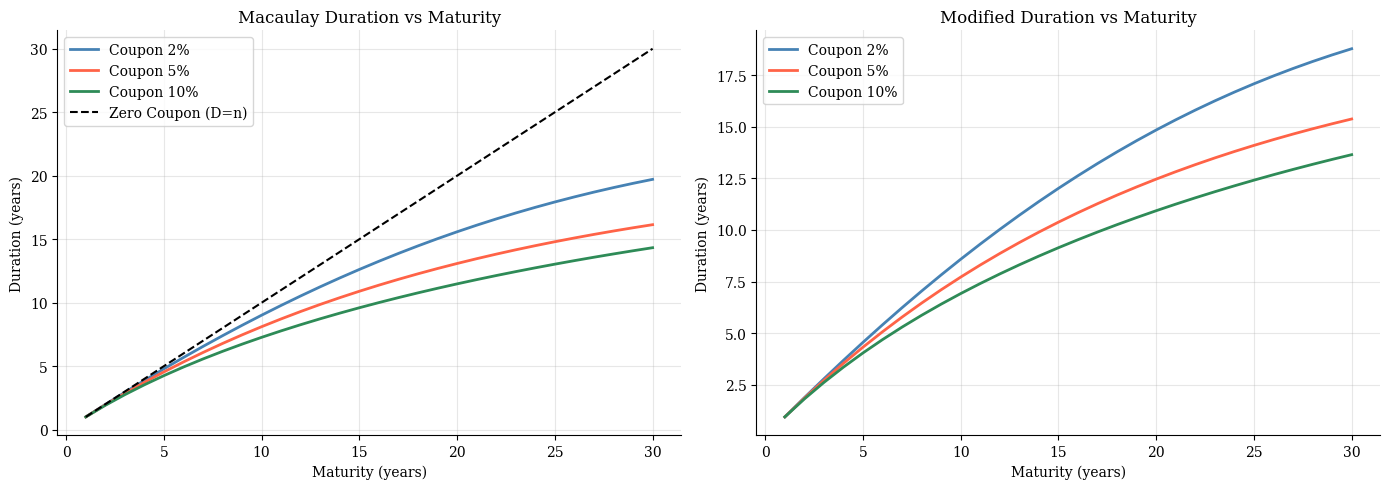

In [16]:
# ---- Duration vs maturity for different coupon rates ---- #
maturities   = np.arange(1, 31)
coupon_rates = [0.02, 0.05, 0.10]
colors       = ["steelblue", "tomato", "seagreen"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cr, col in zip(coupon_rates, colors):
    durations  = []
    mod_durs   = []
    for mat in maturities:
        b = VanillaBond(cr, 1000, mat, 1)
        m = b.risk_metrics(0.05)
        durations.append(m["Mac_Duration"])
        mod_durs.append(m["Mod_Duration"])

    axes[0].plot(maturities, durations, color=col, lw=2,
                 label=f"Coupon {cr:.0%}")
    axes[1].plot(maturities, mod_durs,  color=col, lw=2,
                 label=f"Coupon {cr:.0%}")

# Zero coupon benchmark
zc_durations = list(maturities)   # D_mac = n for zero coupon
axes[0].plot(maturities, zc_durations, "k--", lw=1.5,
             label="Zero Coupon (D=n)")

for ax, title in zip(axes,
                     ["Macaulay Duration vs Maturity",
                      "Modified Duration vs Maturity"]):
    ax.set_xlabel("Maturity (years)")
    ax.set_ylabel("Duration (years)")
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.savefig("../figures/01_duration.png", dpi=150)
plt.show()

---
## 4. Price Approximation: Duration vs Duration + Convexity

Second-order Taylor approximation:
$$\Delta P \approx -D_{mod} \cdot P \cdot \Delta y + \frac{1}{2} \cdot Cx \cdot P \cdot (\Delta y)^2$$

We compare this against the **exact** price change to show that convexity materially improves approximation for large yield moves.

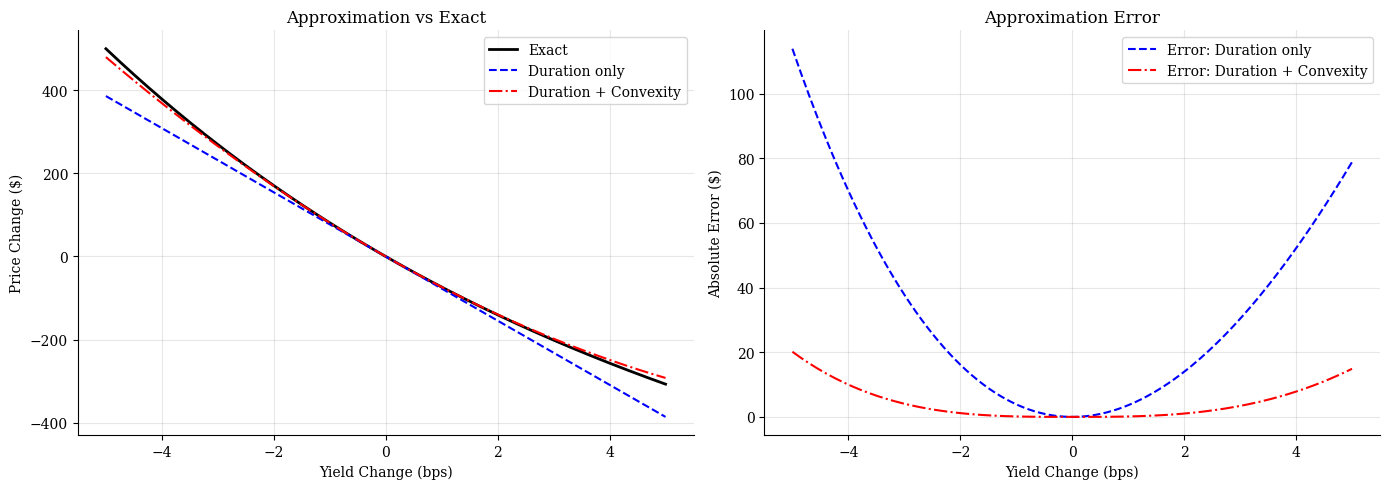

Error at +100bps:
  Duration only:         $3.4751
  Duration + Convexity:  $0.1256


In [17]:
r0     = 0.05
dy_vec = np.linspace(-0.05, 0.05, 200)
m0     = bond.risk_metrics(r0)
P0     = m0["Price"]
D_mod  = m0["Mod_Duration"]
Cx     = m0["Convexity"]

# Duration only (1st order)
dP_dur = -D_mod * P0 * dy_vec

# Duration + Convexity (2nd order)
dP_cx  = -D_mod * P0 * dy_vec + 0.5 * Cx * P0 * dy_vec**2

# Exact
dP_exact = np.array([bond.bond_price(r0 + dy) - P0
                     for dy in dy_vec])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: price change comparison
axes[0].plot(dy_vec * 100, dP_exact, "k-",  lw=2,
             label="Exact")
axes[0].plot(dy_vec * 100, dP_dur,   "b--", lw=1.5,
             label="Duration only")
axes[0].plot(dy_vec * 100, dP_cx,    "r-.", lw=1.5,
             label="Duration + Convexity")
axes[0].set_xlabel("Yield Change (bps)")
axes[0].set_ylabel("Price Change ($)")
axes[0].set_title("Approximation vs Exact")
axes[0].legend()

# Right: approximation error
err_dur = np.abs(dP_exact - dP_dur)
err_cx  = np.abs(dP_exact - dP_cx)
axes[1].plot(dy_vec * 100, err_dur, "b--", lw=1.5,
             label="Error: Duration only")
axes[1].plot(dy_vec * 100, err_cx,  "r-.", lw=1.5,
             label="Error: Duration + Convexity")
axes[1].set_xlabel("Yield Change (bps)")
axes[1].set_ylabel("Absolute Error ($)")
axes[1].set_title("Approximation Error")
axes[1].legend()

plt.tight_layout()
plt.savefig("../figures/01_approximation.png", dpi=150)
plt.show()

# Print error at +/- 100bps
idx_100  = np.argmin(np.abs(dy_vec - 0.01))
print(f"Error at +100bps:")
print(f"  Duration only:         ${err_dur[idx_100]:.4f}")
print(f"  Duration + Convexity:  ${err_cx[idx_100]:.4f}")

---
## 5. Summary

| Bond | Price | Mac Dur | Mod Dur | Convexity | DV01 |
|------|-------|---------|---------|-----------|------|

In [18]:
# ---- Compare bonds with different characteristics ---- #
bonds_config = [
    {"label": "5% / 10y / annual",    "cr": 0.05, "mat": 10, "freq": 1},
    {"label": "5% / 10y / semi-ann",  "cr": 0.05, "mat": 10, "freq": 2},
    {"label": "5% / 30y / annual",    "cr": 0.05, "mat": 30, "freq": 1},
    {"label": "2% / 10y / annual",    "cr": 0.02, "mat": 10, "freq": 1},
    {"label": "10% / 10y / annual",   "cr": 0.10, "mat": 10, "freq": 1},
    {"label": "0% / 10y (zero cpn)",  "cr": 0.00, "mat": 10, "freq": 1},
]

rows = []
for cfg in bonds_config:
    b = VanillaBond(cfg["cr"], 1000, cfg["mat"], cfg["freq"])
    m = b.risk_metrics(0.05)
    rows.append({
        "Bond":       cfg["label"],
        "Price":      f"{m['Price']:.2f}",
        "Mac Dur":    f"{m['Mac_Duration']:.3f}",
        "Mod Dur":    f"{m['Mod_Duration']:.3f}",
        "Convexity":  f"{m['Convexity']:.3f}",
        "DV01":       f"{m['DV01']:.4f}"
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

               Bond   Price Mac Dur Mod Dur Convexity   DV01
  5% / 10y / annual 1000.00   8.108   7.722    74.998 0.7722
5% / 10y / semi-ann 1000.00   7.989   7.795   286.910 0.7795
  5% / 30y / annual 1000.00  16.141  15.372   350.467 1.5372
  2% / 10y / annual  768.35   9.015   8.586    86.875 0.6597
 10% / 10y / annual 1386.09   7.270   6.924    64.024 0.9597
0% / 10y (zero cpn)  613.91  10.000   9.524    99.773 0.5847


---
## Key Observations

1. **Zero coupon bond:** $D_{mac} = n$ exactly — the only case
   where duration equals maturity.

2. **Higher coupon → lower duration:** earlier cash flows reduce
   the weighted average time.

3. **Semi-annual vs annual:** same duration in years, but the
   periodic yield changes.

4. **Convexity is always positive** for vanilla bonds: the
   price-yield curve is convex, meaning gains exceed losses
   for equal yield moves.

5. **Duration + Convexity** approximation is dramatically more
   accurate than duration alone for moves > 50bps.